# Accuracy vs. Sparsity Curves

This notebook aggregates results from all algorithms (except GA and IMP) and plots test accuracy as a function of sparsity for each Dataset × Architecture combination.

In [3]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# Define which algorithms to include (exclude GA and IMP)
ALGO_DIRS = [
    'earlybird',
    'grasp',
    'hybrid',
    'hybrid-improve',
    'synflow',
]
RESULTS_ROOT = '../results/'

# SynFlow rho-to-target mapping provided by experiment design.
SYNFLOW_RHO_TO_TARGET = {
    10.0: 0.9,
    1.43: 0.3,
    2.5: 0.6,
}


def _normalize_target_sparsity(value):
    if value is None:
        return None
    try:
        return round(float(value), 2)
    except (TypeError, ValueError):
        return None


# Helper to extract info from a results.json file
def extract_result_info(filepath, algo):
    with open(filepath, 'r') as f:
        data = json.load(f)

    algorithm = algo

    cfg = data.get('config', {}) if isinstance(data.get('config', {}), dict) else {}
    dataset = cfg.get('dataset') or cfg.get('dataset_name')
    arch = cfg.get('model') or cfg.get('model_name')

    # Prefer explicit target sparsity.
    target_sparsity = _normalize_target_sparsity(cfg.get('target_sparsity'))

    final_results = data.get('final_results', {})
    pruning = data.get('pruning', {})

    final_sparsity = final_results.get('final_sparsity')
    if final_sparsity is None:
        final_sparsity = final_results.get('overall_sparsity')
    if final_sparsity is None:
        final_sparsity = pruning.get('overall_sparsity')

    # SynFlow: map rho to target sparsity according to experiment setup.
    if target_sparsity is None and algorithm == 'synflow':
        rho = cfg.get('rho')
        try:
            rho_key = round(float(rho), 2)
            if rho_key in SYNFLOW_RHO_TO_TARGET:
                target_sparsity = SYNFLOW_RHO_TO_TARGET[rho_key]
        except (TypeError, ValueError):
            pass

    # Generic fallbacks for methods that do not store target_sparsity.
    if target_sparsity is None:
        target_sparsity = _normalize_target_sparsity(final_results.get('overall_sparsity'))
    if target_sparsity is None:
        target_sparsity = _normalize_target_sparsity(pruning.get('overall_sparsity'))

    if target_sparsity is None:
        exp_name = os.path.basename(os.path.dirname(filepath))
        sparsity_match = re.search(r's(?:parsity)?([0-9]*\.?[0-9]+)', exp_name)
        if sparsity_match:
            target_sparsity = _normalize_target_sparsity(sparsity_match.group(1))

    best_acc = final_results.get('best_test_accuracy')
    if best_acc is None:
        best_acc = final_results.get('final_test_accuracy')
    if best_acc is None:
        best_acc = data.get('final_test_acc') or data.get('best_test_acc')
    if best_acc is None and 'phases' in data:
        best_acc = max(phase.get('best_test_acc', 0) for phase in data['phases'])

    return {
        'algorithm': algorithm,
        'dataset': dataset,
        'architecture': arch,
        'target_sparsity': target_sparsity,
        'final_sparsity': final_sparsity,
        'best_test_accuracy': best_acc,
        'file': filepath,
    }


# Aggregate all results
results = []
for algo in ALGO_DIRS:
    algo_dir = os.path.join(RESULTS_ROOT, algo)
    for root, dirs, files in os.walk(algo_dir):
        for fname in files:
            if fname == 'results.json':
                info = extract_result_info(os.path.join(root, fname), algo)
                if info['target_sparsity'] is not None and info['best_test_accuracy'] is not None:
                    results.append(info)

df = pd.DataFrame(results)
df['target_sparsity'] = pd.to_numeric(df['target_sparsity'], errors='coerce')
df['best_test_accuracy'] = pd.to_numeric(df['best_test_accuracy'], errors='coerce')
df = df.dropna(subset=['target_sparsity', 'best_test_accuracy'])
# Always convert target sparsity to percent (decimal to percent)
df['target_sparsity_percent'] = df['target_sparsity'] * 100
df = df.sort_values(['dataset', 'architecture', 'algorithm', 'target_sparsity_percent'])
df.head()

,algorithm,dataset,architecture,target_sparsity,final_sparsity,best_test_accuracy,file,target_sparsity_percent
3,earlybird,cifar10,resnet20,0.3,0.323226,89.94,../results/earlybird/eb_resnet20_cifar10_spars...,30.0
4,earlybird,cifar10,resnet20,0.6,0.486425,80.43,../results/earlybird/eb_resnet20_cifar10_spars...,60.0
1,earlybird,cifar10,resnet20,0.9,NaN,68.93,../results/earlybird/eb_resnet20_cifar10_spars...,90.0
9,grasp,cifar10,resnet20,0.3,0.300001,90.58,../results/grasp/grasp_resnet20_cifar10_s0.3_s...,30.0
8,grasp,cifar10,resnet20,0.6,0.600001,90.00,../results/grasp/grasp_resnet20_cifar10_s0.6_s...,60.0


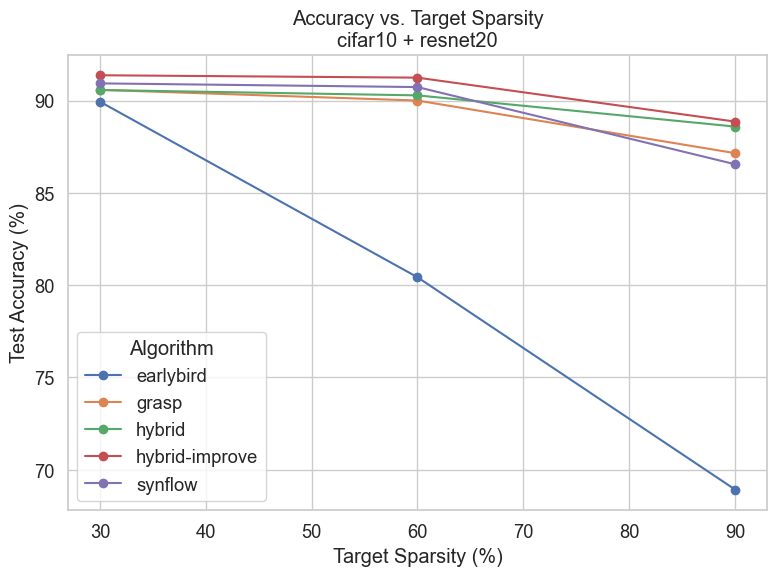

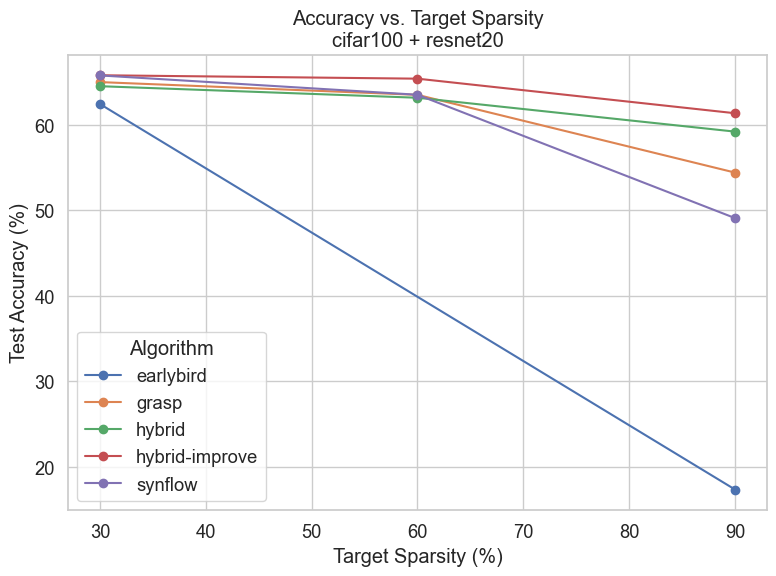

In [4]:
# Plot Accuracy vs. Target Sparsity for each (dataset, architecture)
sns.set(style="whitegrid", font_scale=1.2)
for (dataset, arch), group in df.groupby(["dataset", "architecture"]):
    plt.figure(figsize=(8, 6))
    for algo, algo_df in group.groupby("algorithm"):
        plt.plot(
            algo_df["target_sparsity_percent"],
            algo_df["best_test_accuracy"],
            marker="o", label=algo
        )
    plt.xlabel("Target Sparsity (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title(f"Accuracy vs. Target Sparsity\n{dataset} + {arch}")
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.show()

## Accuracy Drop vs. Sparsity

This plot shows how much accuracy is lost at each sparsity level for each algorithm, highlighting which methods degrade least at high sparsity. Accuracy drop is computed as the difference between the dense (unpruned) accuracy and the pruned accuracy at each sparsity.

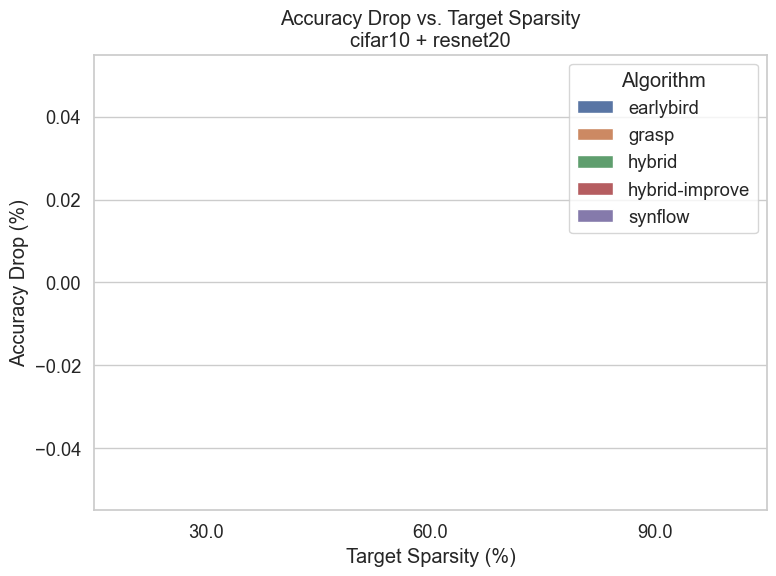

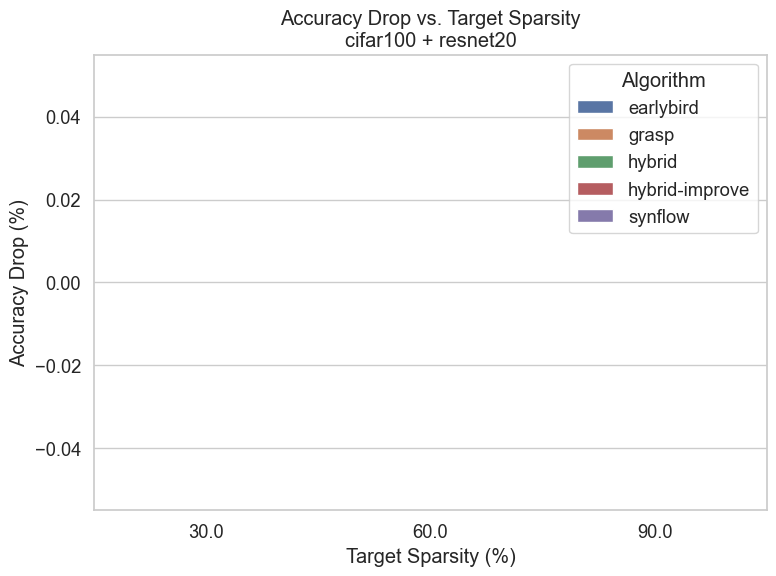

In [5]:
# Compute dense accuracy for each (algorithm, dataset, architecture)
dense_acc = (
    df[df["target_sparsity_percent"] < 1]
    .groupby(["algorithm", "dataset", "architecture"])["best_test_accuracy"]
    .max()
    .reset_index()
    .rename(columns={"best_test_accuracy": "dense_accuracy"})
)

# Merge dense accuracy into all rows
merged = pd.merge(
    df,
    dense_acc,
    on=["algorithm", "dataset", "architecture"],
    how="left"
)
# Compute accuracy drop
merged["accuracy_drop"] = merged["dense_accuracy"] - merged["best_test_accuracy"]

# Only keep pruned results (target sparsity > 0)
pruned = merged[merged["target_sparsity_percent"] >= 1].copy()

# Plot: Grouped bar plot by target sparsity, colored by algorithm, faceted by dataset/architecture
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

for (dataset, arch), group in pruned.groupby(["dataset", "architecture"]):
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=group,
        x="target_sparsity_percent",
        y="accuracy_drop",
        hue="algorithm",
        dodge=True
    )
    plt.xlabel("Target Sparsity (%)")
    plt.ylabel("Accuracy Drop (%)")
    plt.title(f"Accuracy Drop vs. Target Sparsity\n{dataset} + {arch}")
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.show()

## Efficiency Trade-off / Pareto Frontier

This plot visualizes the trade-off between test accuracy and FLOPs reduction for each experiment, highlighting the most efficient solutions (Pareto frontier). Each point represents a run (algorithm, dataset, architecture, sparsity), with color indicating the algorithm and size optionally representing training cost.

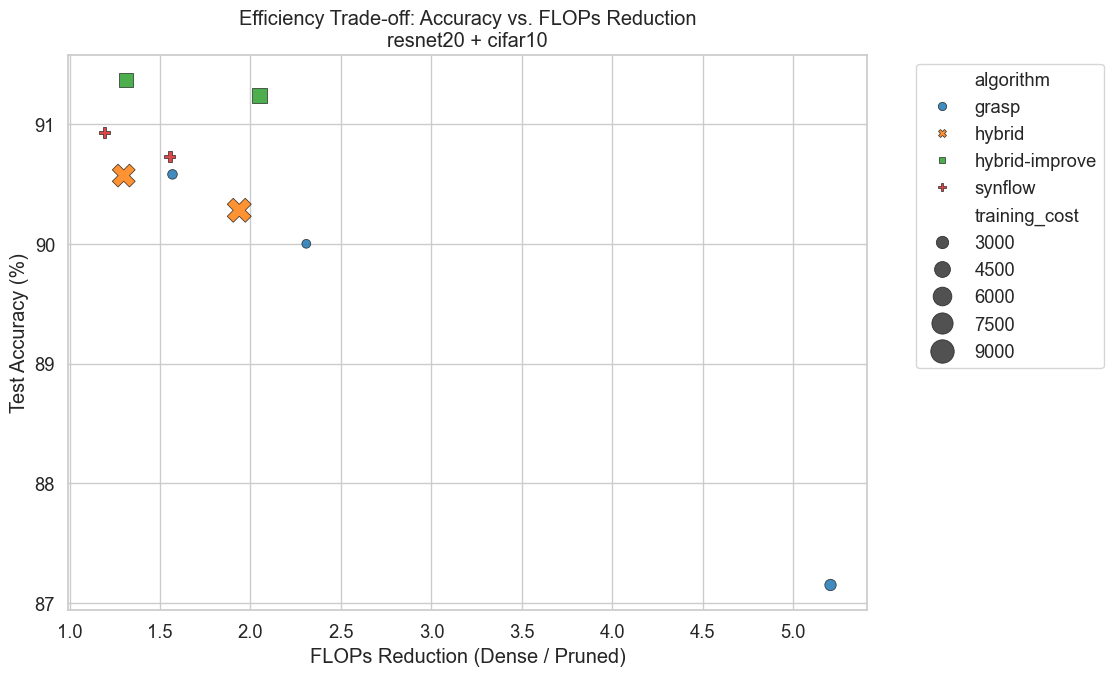

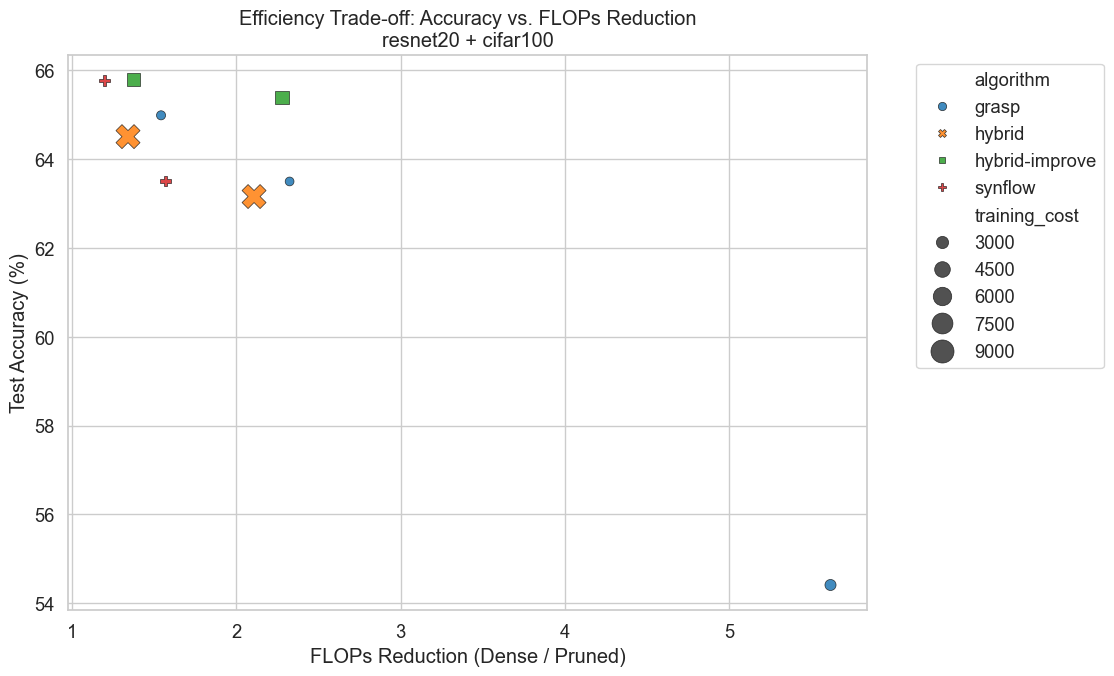

In [6]:
# --- Efficiency Trade-off / Pareto Frontier ---
# Extract additional fields from each results.json for Pareto plot

def extract_pareto_fields(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    final_results = data.get('final_results', {})
    # Try to get all relevant fields, fallback to None if missing
    flops_reduction = final_results.get('flops_reduction')
    dense_flops = final_results.get('dense_flops')
    pruned_flops = final_results.get('pruned_flops')
    training_cost = final_results.get('training_computational_cost_seconds')
    # If flops_reduction missing but both flops present, compute it
    if flops_reduction is None and dense_flops and pruned_flops:
        try:
            flops_reduction = float(dense_flops) / float(pruned_flops)
        except Exception:
            flops_reduction = None
    return {
        'flops_reduction': flops_reduction,
        'dense_flops': dense_flops,
        'pruned_flops': pruned_flops,
        'training_cost': training_cost
    }

# Re-aggregate with extra fields
pareto_results = []
for algo in ALGO_DIRS:
    algo_dir = os.path.join(RESULTS_ROOT, algo)
    for root, dirs, files in os.walk(algo_dir):
        for fname in files:
            if fname == 'results.json':
                info = extract_result_info(os.path.join(root, fname), algo)
                if info['final_sparsity'] is not None and info['best_test_accuracy'] is not None:
                    extra = extract_pareto_fields(os.path.join(root, fname))
                    info.update(extra)
                    pareto_results.append(info)

pareto_df = pd.DataFrame(pareto_results)
pareto_df['flops_reduction'] = pd.to_numeric(pareto_df['flops_reduction'], errors='coerce')
pareto_df['best_test_accuracy'] = pd.to_numeric(pareto_df['best_test_accuracy'], errors='coerce')
pareto_df['training_cost'] = pd.to_numeric(pareto_df['training_cost'], errors='coerce')
pareto_df = pareto_df.dropna(subset=['flops_reduction', 'best_test_accuracy'])

# Plot: Separate for each (dataset, architecture)
sns.set(style="whitegrid", font_scale=1.2)
for (dataset, arch), group in pareto_df.groupby(['dataset', 'architecture']):
    plt.figure(figsize=(9, 7))
    scatter = sns.scatterplot(
        data=group,
        x='flops_reduction',
        y='best_test_accuracy',
        hue='algorithm',
        size='training_cost',
        style='algorithm',
        alpha=0.85,
        palette='tab10',
        sizes=(40, 300),
        edgecolor='k',
        legend='brief'
    )
    plt.xlabel('FLOPs Reduction (Dense / Pruned)')
    plt.ylabel('Test Accuracy (%)')
    plt.title(f'Efficiency Trade-off: Accuracy vs. FLOPs Reduction\n{arch} + {dataset}')
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Training / Convergence Curves (Per Key Config)

This section visualizes the training and convergence behavior for each (model, dataset) configuration. For each run, we plot Test Accuracy vs. Epoch and Test Loss vs. Epoch, comparing the dense model to pruned models at different sparsities. Data is extracted from summary.csv (if available) or from train history in results.json.

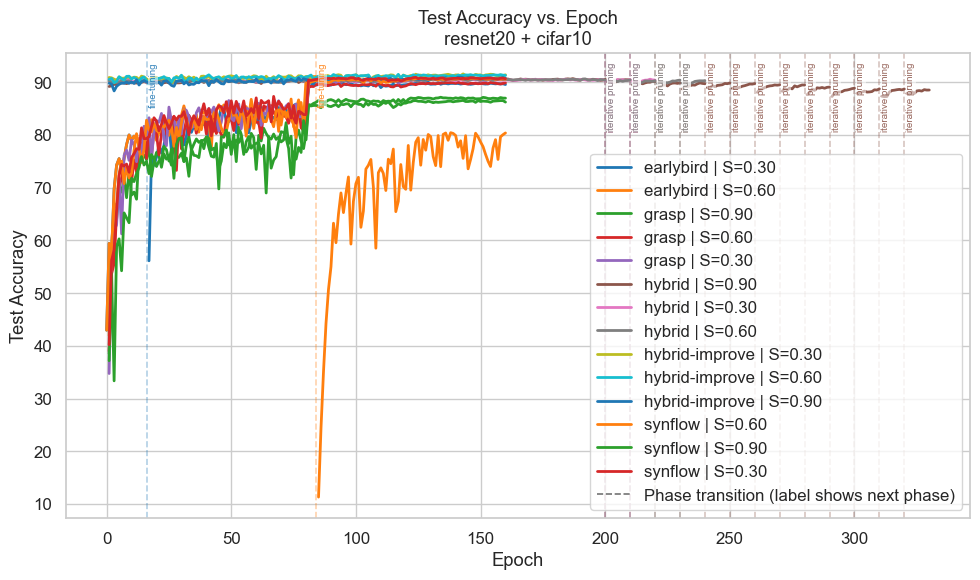

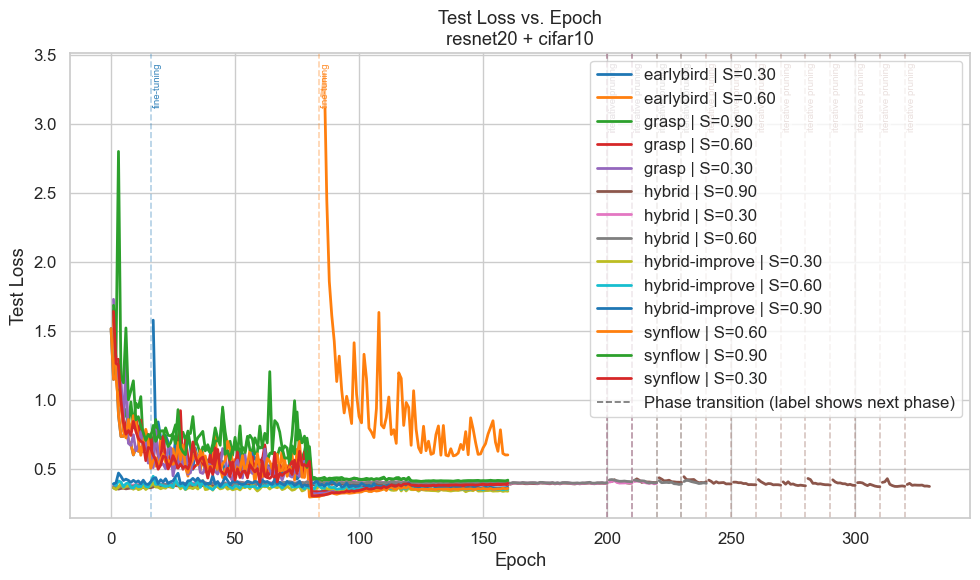

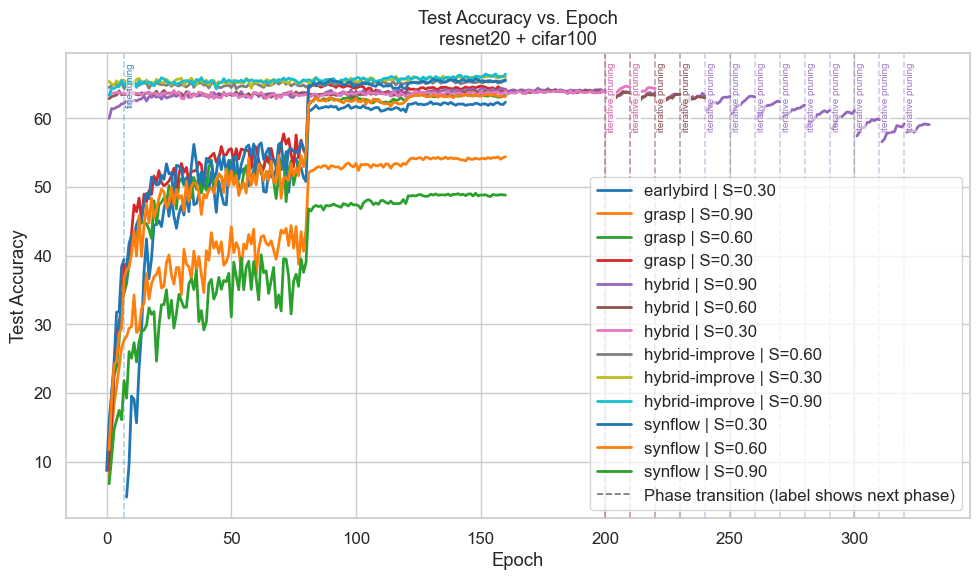

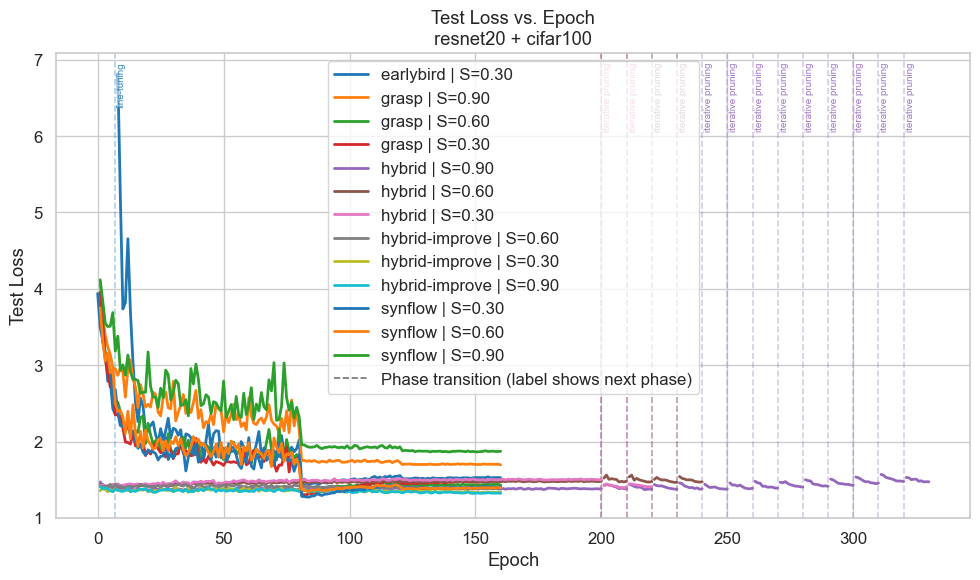

In [11]:
import glob
import json
import os
import re
from itertools import cycle
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Hybrid-Improve should be visualized on its base training horizon.
ALGO_DIRS = globals().get("ALGO_DIRS", [
    'earlybird',
    'grasp',
    'hybrid',
    'hybrid-improve',
    'synflow',
])
RESULTS_ROOT = globals().get("RESULTS_ROOT", '../results/')
EPOCH_CAP_BY_ALGO = {
    'hybrid-improve': 160,
}


def _make_history_df(block, start_epoch=1):
    if not isinstance(block, dict):
        return None

    accs = block.get('test_accs')
    if accs is None:
        accs = block.get('test_acc')
    losses = block.get('test_losses')
    if losses is None:
        losses = block.get('test_loss')

    accs = list(accs or [])
    losses = list(losses or [])
    n = min(len(accs), len(losses))
    if n == 0:
        return None

    epochs = block.get('epoch')
    if epochs is not None:
        epochs = list(epochs)[:n]
    else:
        epochs = list(range(start_epoch, start_epoch + n))

    return pd.DataFrame({
        'epoch': epochs,
        'test_acc': accs[:n],
        'test_loss': losses[:n],
    })


def _cap_history_epochs(history_df, algo):
    limit = EPOCH_CAP_BY_ALGO.get(algo)
    if limit is None or history_df is None:
        return history_df
    if len(history_df) <= limit:
        return history_df
    capped = history_df.iloc[:limit].copy()
    capped['epoch'] = list(range(1, len(capped) + 1))
    return capped


def extract_phase_segments_from_json(json_path, algo):
    with open(json_path, 'r') as f:
        data = json.load(f)

    segments = []
    total_cap = EPOCH_CAP_BY_ALGO.get(algo)
    epochs_used = 0

    def _append_segment(label, history_df):
        nonlocal epochs_used
        if history_df is None or history_df.empty:
            return

        if total_cap is not None:
            remaining = total_cap - epochs_used
            if remaining <= 0:
                return
            if len(history_df) > remaining:
                history_df = history_df.iloc[:remaining].copy()
                history_df['epoch'] = list(range(int(history_df['epoch'].iloc[0]), int(history_df['epoch'].iloc[0]) + len(history_df)))

        segments.append({
            'label': label,
            'history': history_df,
        })
        epochs_used += len(history_df)

    # EarlyBird stores two explicit histories: search + finetune.
    if algo == 'earlybird':
        _append_segment('search', _make_history_df(data.get('search_history'), start_epoch=1))
        search_hist = segments[-1]['history'] if segments else None
        search_end_epoch = int(search_hist['epoch'].iloc[-1]) if search_hist is not None else None
        _append_segment('finetune', _make_history_df(data.get('finetune_history'), start_epoch=(search_end_epoch + 1) if search_end_epoch is not None else 1))
        if segments:
            return segments

    # Hybrid / Hybrid-Improve store a phases array with per-phase histories.
    phases = data.get('phases', [])
    if phases:
        current_epoch = 1
        for idx, phase in enumerate(phases):
            phase_hist = _make_history_df(phase, start_epoch=current_epoch)
            if phase_hist is None:
                continue
            phase_hist = _cap_history_epochs(phase_hist, algo)
            phase_label = phase.get('label') or f'phase_{idx + 1}'
            _append_segment(phase_label, phase_hist)
            if not segments:
                continue
            current_epoch = int(segments[-1]['history']['epoch'].iloc[-1]) + 1
            if total_cap is not None and epochs_used >= total_cap:
                break
        if segments:
            return segments

    # Fallback for methods with a single continuous history block.
    for key, label in (
        ('initial_training', 'initial_training'),
        ('training', 'training'),
        ('finetune_history', 'finetune_history'),
        ('search_history', 'search_history'),
    ):
        hist = _make_history_df(data.get(key), start_epoch=1)
        if hist is not None:
            hist = _cap_history_epochs(hist, algo)
            return [{'label': label, 'history': hist}]

    hist = _make_history_df(data, start_epoch=1)
    if hist is not None:
        hist = _cap_history_epochs(hist, algo)
        return [{'label': 'history', 'history': hist}]

    return []


def _phase_display_label(raw_label):
    label = str(raw_label or '').strip().lower().replace('_', '-')
    if label.startswith('iter-') or label.startswith('iterative'):
        return 'iterative pruning'

    mapping = {
        'one-shot': 'one-shot pruning',
        'search': 'searching',
        'search-history': 'searching',
        'finetune': 'fine-tuning',
        'finetune-history': 'fine-tuning',
        'initial-training': 'initial training',
        'training': 'training',
    }
    return mapping.get(label, label.replace('-', ' '))


# Aggregate histories for each (dataset, architecture, algorithm, target_sparsity)
histories = []
synflow_rho_to_target = globals().get('SYNFLOW_RHO_TO_TARGET', {10.0: 0.9, 1.43: 0.3, 2.5: 0.6})

for algo in ALGO_DIRS:
    algo_dir = os.path.join(RESULTS_ROOT, algo)
    for exp_dir in glob.glob(os.path.join(algo_dir, '*')):
        exp_name = os.path.basename(exp_dir)
        json_path = os.path.join(exp_dir, 'results.json')
        if not os.path.exists(json_path):
            continue

        with open(json_path, 'r') as f:
            data = json.load(f)

        cfg = data.get('config', {}) if isinstance(data.get('config', {}), dict) else {}
        dataset = cfg.get('dataset') or cfg.get('dataset_name')
        arch = cfg.get('model') or cfg.get('model_name')

        if dataset is None or arch is None:
            parts = exp_name.split('_')
            if len(parts) >= 3:
                arch = arch or parts[1]
                dataset = dataset or parts[2]

        # Use target sparsity first, with SynFlow rho mapping fallback.
        sparsity = cfg.get('target_sparsity')
        if sparsity is None and algo == 'synflow':
            rho = cfg.get('rho')
            try:
                rho_key = round(float(rho), 2)
                sparsity = synflow_rho_to_target.get(rho_key)
            except (TypeError, ValueError):
                pass

        if sparsity is None:
            m = re.search(r's(?:parsity)?([0-9]*\.?[0-9]+)', exp_name)
            if m:
                sparsity = float(m.group(1))

        if sparsity is None:
            sparsity = data.get('final_results', {}).get('overall_sparsity')
        if sparsity is None:
            sparsity = data.get('pruning', {}).get('overall_sparsity')

        try:
            sparsity = float(sparsity)
        except (TypeError, ValueError):
            continue

        run_type = 'dense' if sparsity < 1e-3 else 'pruned'
        segments = extract_phase_segments_from_json(json_path, algo)
        if not segments:
            continue

        histories.append({
            'algorithm': algo,
            'dataset': dataset,
            'architecture': arch,
            'sparsity': sparsity,
            'type': run_type,
            'segments': segments,
        })


# Plot curves for each (dataset, architecture)
sns.set(style="whitegrid", font_scale=1.1)
for (dataset, arch), group in pd.DataFrame(histories).groupby(['dataset', 'architecture']):
    plt.figure(figsize=(10, 6))
    for entry, color in zip(group.itertuples(), cycle(sns.color_palette('tab10'))):
        label = f"{entry.algorithm} | {'Dense' if entry.type == 'dense' else f'S={entry.sparsity:.2f}'}"
        first_segment = True
        for seg_idx, segment in enumerate(entry.segments):
            history = segment['history']
            plt.plot(
                history['epoch'],
                history['test_acc'],
                color=color,
                label=label if first_segment else None,
                linewidth=2.0,
            )
            first_segment = False
            boundary_epoch = int(history['epoch'].iloc[-1])
            if seg_idx < len(entry.segments) - 1:
                next_phase = _phase_display_label(entry.segments[seg_idx + 1].get('label'))
                plt.axvline(
                    boundary_epoch,
                    color=color,
                    linestyle='--',
                    alpha=0.35,
                    linewidth=1.2,
                )
                ax = plt.gca()
                ax.text(
                    boundary_epoch + 0.8,
                    0.98,
                    next_phase,
                    transform=ax.get_xaxis_transform(),
                    rotation=90,
                    ha='left',
                    va='top',
                    fontsize=7,
                    color=color,
                    alpha=0.9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=0.2),
                )
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.title(f'Test Accuracy vs. Epoch\n{arch} + {dataset}')
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    phase_boundary_legend = 'Phase transition (label shows next phase)'
    if phase_boundary_legend not in labels:
        handles.append(Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, alpha=0.55, label=phase_boundary_legend))
        labels.append(phase_boundary_legend)
    ax.legend(handles, labels)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    for entry, color in zip(group.itertuples(), cycle(sns.color_palette('tab10'))):
        label = f"{entry.algorithm} | {'Dense' if entry.type == 'dense' else f'S={entry.sparsity:.2f}'}"
        first_segment = True
        for seg_idx, segment in enumerate(entry.segments):
            history = segment['history']
            plt.plot(
                history['epoch'],
                history['test_loss'],
                color=color,
                label=label if first_segment else None,
                linewidth=2.0,
            )
            first_segment = False
            boundary_epoch = int(history['epoch'].iloc[-1])
            if seg_idx < len(entry.segments) - 1:
                next_phase = _phase_display_label(entry.segments[seg_idx + 1].get('label'))
                plt.axvline(
                    boundary_epoch,
                    color=color,
                    linestyle='--',
                    alpha=0.35,
                    linewidth=1.2,
                )
                ax = plt.gca()
                ax.text(
                    boundary_epoch + 0.8,
                    0.98,
                    next_phase,
                    transform=ax.get_xaxis_transform(),
                    rotation=90,
                    ha='left',
                    va='top',
                    fontsize=7,
                    color=color,
                    alpha=0.9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=0.2),
                )
    plt.xlabel('Epoch')
    plt.ylabel('Test Loss')
    plt.title(f'Test Loss vs. Epoch\n{arch} + {dataset}')
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    phase_boundary_legend = 'Phase transition (label shows next phase)'
    if phase_boundary_legend not in labels:
        handles.append(Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, alpha=0.55, label=phase_boundary_legend))
        labels.append(phase_boundary_legend)
    ax.legend(handles, labels)
    plt.tight_layout()
    plt.show()

## Layer-wise Sparsity Distribution (ResNet-20)

This section visualizes the sparsity of each layer in ResNet-20 for each algorithm and sparsity level. Bar plots show the fraction of pruned weights per layer, revealing whether pruning is balanced or if some layers are overly pruned (layer collapse).

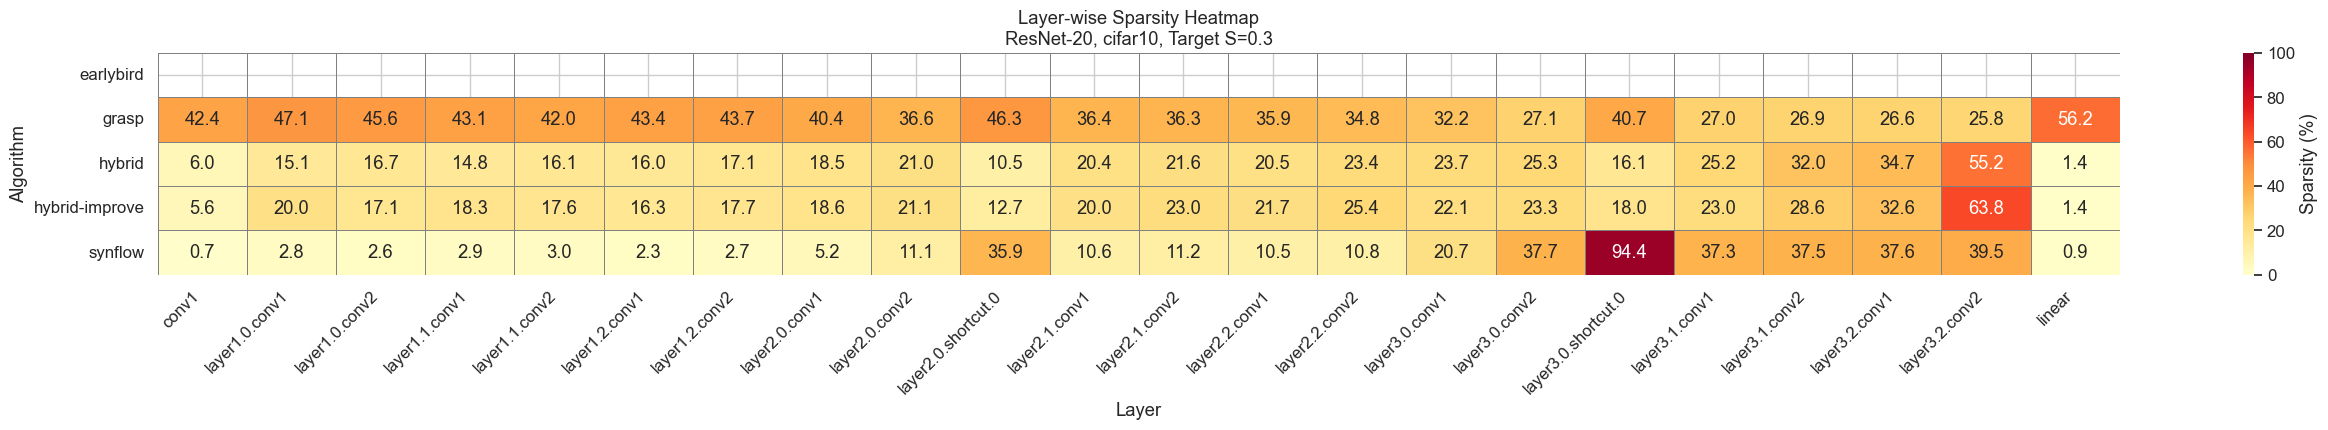

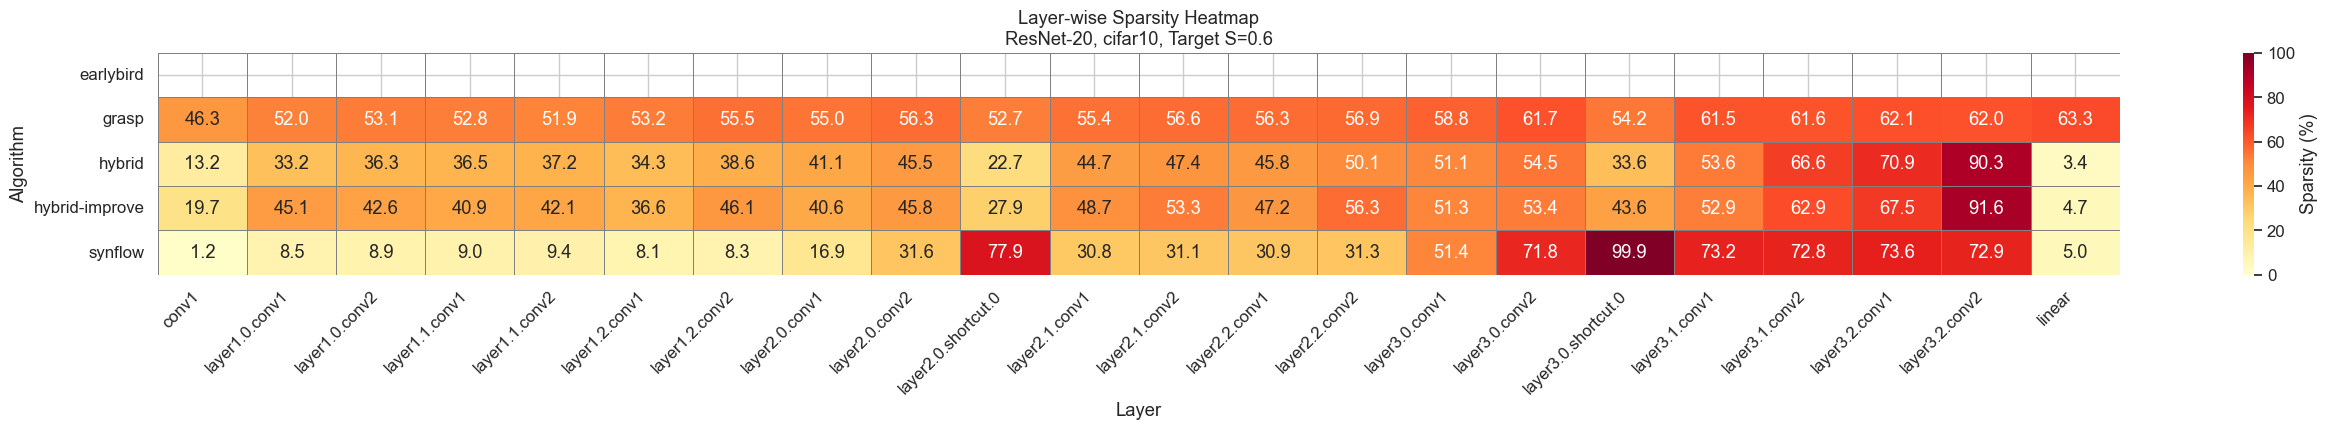

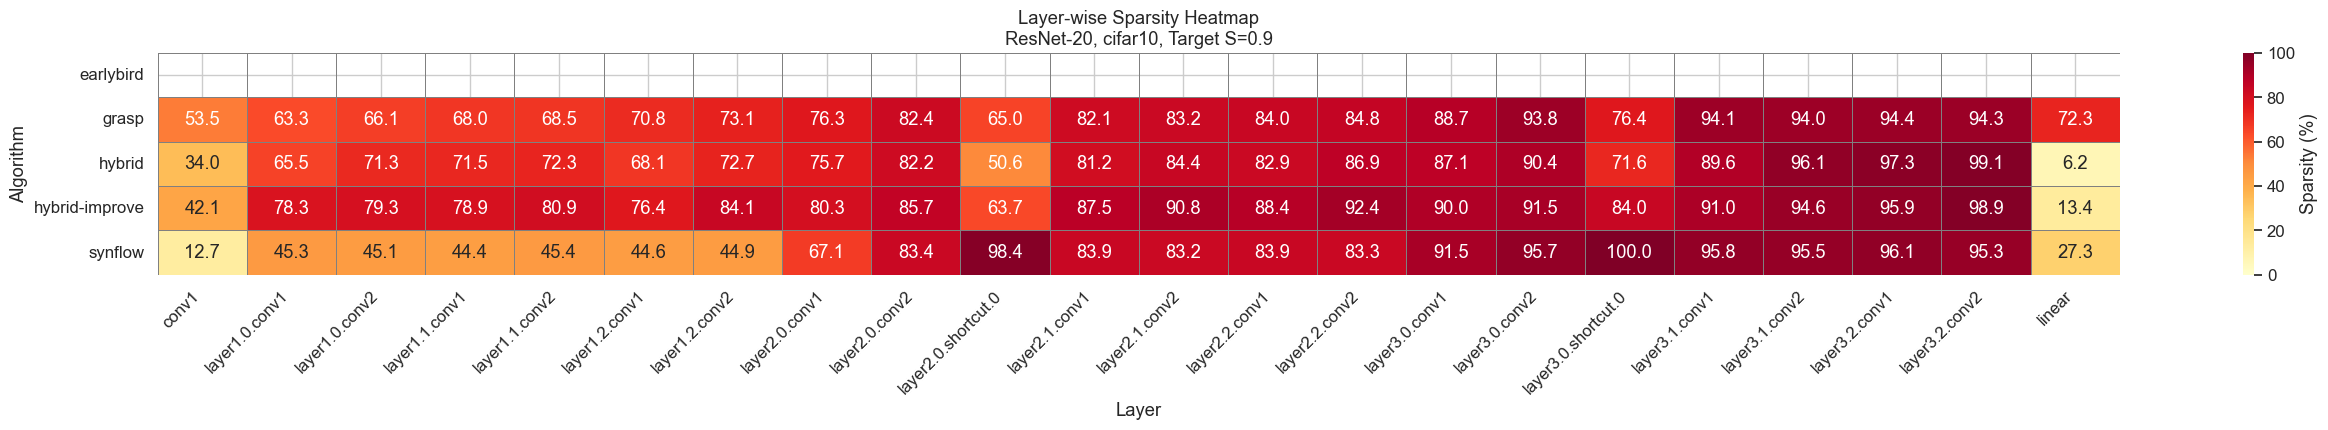

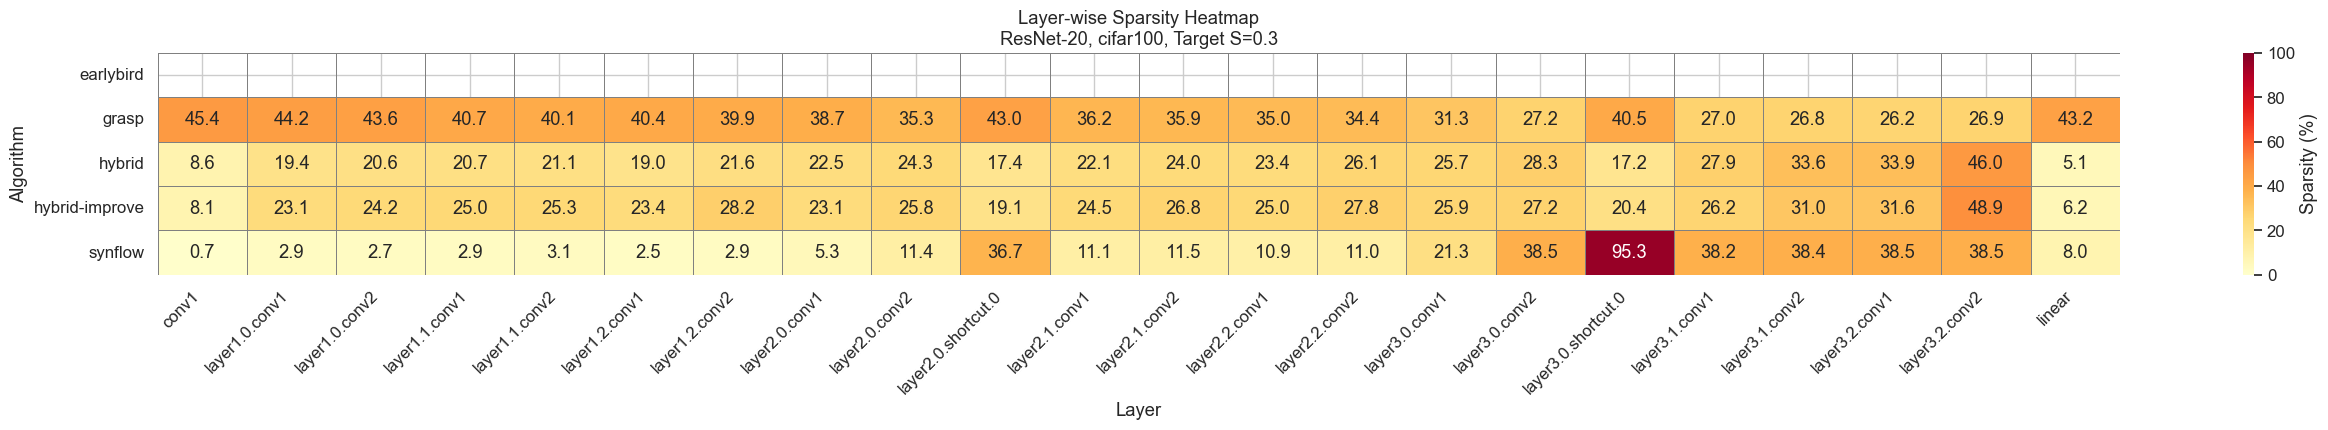

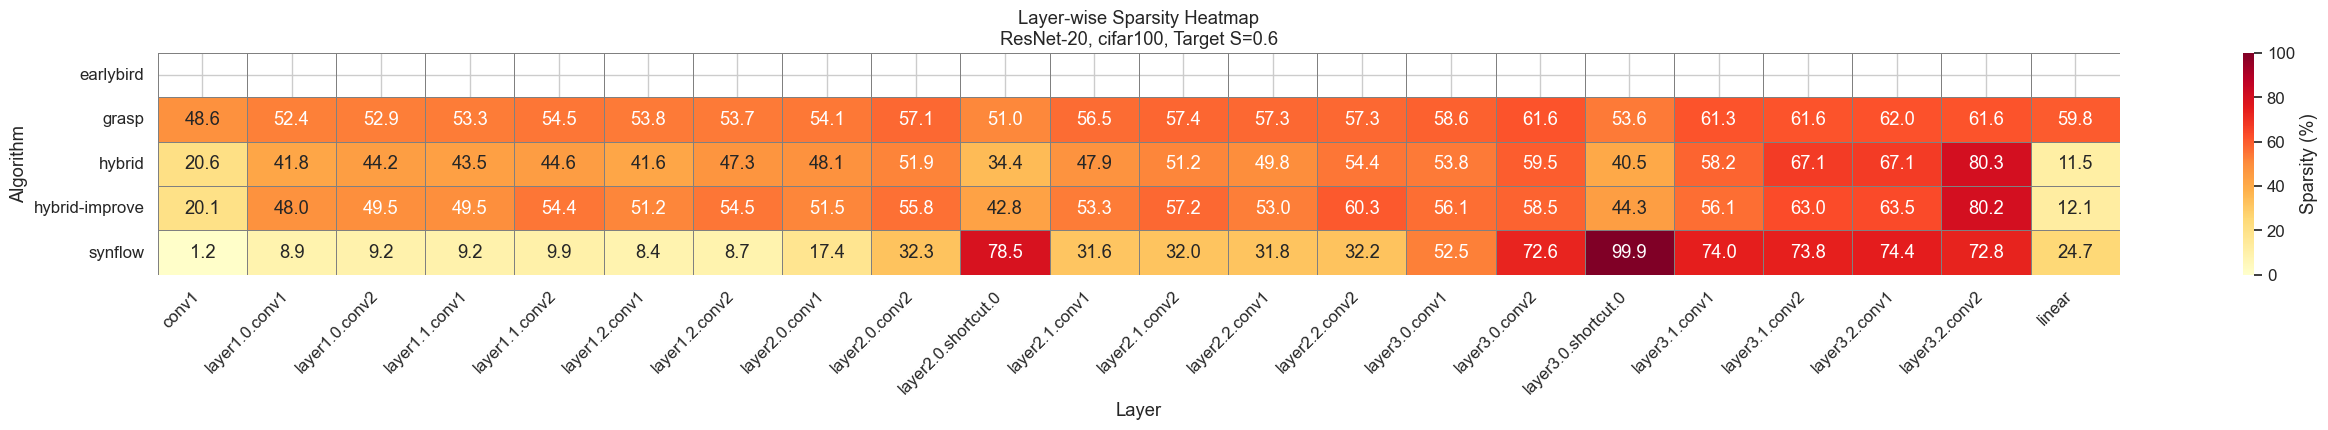

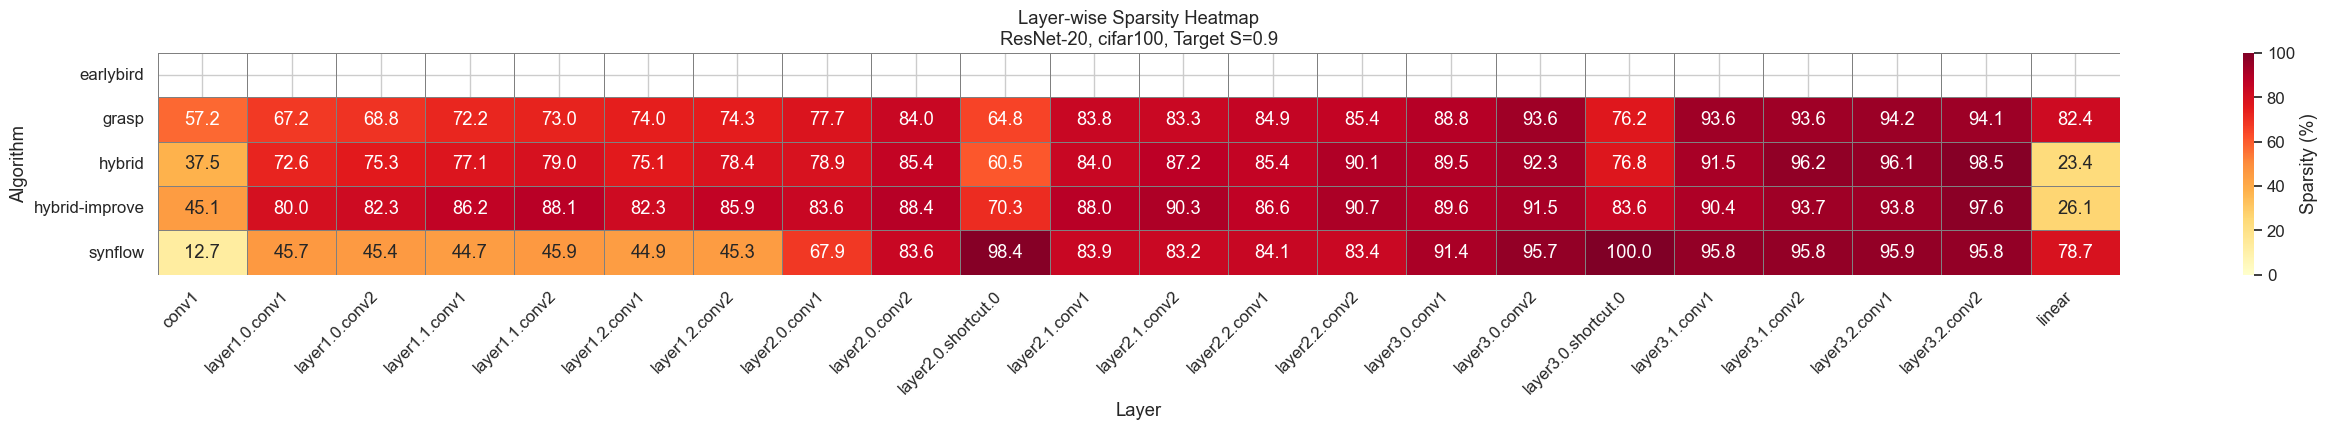

In [8]:
# --- Layer-wise Sparsity Distribution (ResNet-20, Grouped by Target Sparsity) ---

import glob
import re

# SynFlow rho-to-target mapping provided by experiment design.
SYNFLOW_RHO_TO_TARGET = {
    10.0: 0.9,
    1.43: 0.3,
    2.5: 0.6,
}

layer_sparsity_records = []
layer_name_order = []
layer_name_set = set()
all_datasets = set()
all_target_sparsities = set()

for algo in ALGO_DIRS:
    algo_dir = os.path.join(RESULTS_ROOT, algo)
    for exp_dir in glob.glob(os.path.join(algo_dir, "*")):
        exp_name = os.path.basename(exp_dir)

        # Only consider ResNet-20 experiments
        if "resnet20" not in exp_name.lower():
            continue

        json_path = os.path.join(exp_dir, "results.json")
        if not os.path.exists(json_path):
            continue

        with open(json_path, "r") as f:
            data = json.load(f)

        # Use target_sparsity (preferred), then SynFlow rho mapping, then fallback fields.
        target_sparsity = None
        cfg = data.get("config", {})
        if isinstance(cfg, dict):
            target_sparsity = cfg.get("target_sparsity")

        if target_sparsity is None and algo == "synflow":
            rho = cfg.get("rho") if isinstance(cfg, dict) else None
            try:
                rho_key = round(float(rho), 2)
                if rho_key in SYNFLOW_RHO_TO_TARGET:
                    target_sparsity = SYNFLOW_RHO_TO_TARGET[rho_key]
            except (TypeError, ValueError):
                pass

        if target_sparsity is None:
            target_sparsity = data.get("final_results", {}).get("overall_sparsity")
        if target_sparsity is None:
            target_sparsity = data.get("pruning", {}).get("overall_sparsity")

        if target_sparsity is None:
            sparsity_match = re.search(r"s(?:parsity)?([0-9]*\.?[0-9]+)", exp_name)
            if sparsity_match:
                target_sparsity = float(sparsity_match.group(1))

        if target_sparsity is None:
            continue

        # Normalize to merge near-identical values like 0.900005 and 0.9.
        target_sparsity = round(float(target_sparsity), 2)

        # Unified extraction for all algorithms
        layer_sparsities = None

        # 1) Try last phase (hybrid, hybrid-improve)
        phases = data.get("phases", [])
        if phases:
            layer_sparsities = phases[-1].get("layer_sparsities")

        # 2) Try final_results (earlybird)
        if layer_sparsities is None or not isinstance(layer_sparsities, dict):
            final_results = data.get("final_results", {})
            layer_sparsities = final_results.get("layer_sparsities")

        # 3) Try pruning (grasp, synflow)
        if layer_sparsities is None or not isinstance(layer_sparsities, dict):
            pruning = data.get("pruning", {})
            layer_sparsities = pruning.get("layer_sparsities")

        if layer_sparsities is None or not isinstance(layer_sparsities, dict):
            continue

        # Get dataset from config or fallback to experiment name
        dataset = cfg.get("dataset") or cfg.get("dataset_name") if isinstance(cfg, dict) else None
        if dataset is None:
            parts = exp_name.split("_")
            if len(parts) >= 3:
                dataset = parts[2]

        if dataset is None:
            continue

        all_datasets.add(dataset)
        all_target_sparsities.add(target_sparsity)

        # Track layer order using first valid run
        if not layer_name_order:
            layer_name_order = list(layer_sparsities.keys())
        layer_name_set.update(layer_sparsities.keys())

        for lname, spars in layer_sparsities.items():
            layer_sparsity_records.append({
                "algorithm": algo,
                "dataset": dataset,
                "target_sparsity": target_sparsity,
                "layer": lname,
                "layer_sparsity": float(spars) * 100.0,
            })

# Use consistent layer order for plotting
if not layer_name_order:
    layer_name_order = sorted(layer_name_set)

layer_sparsity_df = pd.DataFrame(layer_sparsity_records)
if layer_sparsity_df.empty:
    raise ValueError("No layer-wise sparsity data found for ResNet-20.")

layer_sparsity_df["layer"] = pd.Categorical(
    layer_sparsity_df["layer"],
    categories=layer_name_order,
    ordered=True,
)

# Plot heatmaps grouped by dataset and target sparsity
sns.set(style="whitegrid", font_scale=1.1)
valid_datasets = sorted(d for d in all_datasets if d is not None)
valid_target_sparsities = sorted(s for s in all_target_sparsities if s is not None)

for dataset in valid_datasets:
    for target_sparsity in valid_target_sparsities:
        group = layer_sparsity_df[
            (layer_sparsity_df["dataset"] == dataset)
            & (layer_sparsity_df["target_sparsity"] == target_sparsity)
        ]
        if group.empty:
            continue

        pivot = group.pivot(index="algorithm", columns="layer", values="layer_sparsity")
        pivot = pivot.reindex(index=sorted(ALGO_DIRS))

        plt.figure(figsize=(1.2 * len(layer_name_order), 2 + 0.5 * len(pivot)))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".1f",
            cmap="YlOrRd",
            cbar_kws={"label": "Sparsity (%)"},
            linewidths=0.5,
            linecolor="gray",
            vmin=0,
            vmax=100,
        )
        plt.xlabel("Layer")
        plt.ylabel("Algorithm")
        plt.title(f"Layer-wise Sparsity Heatmap\nResNet-20, {dataset}, Target S={target_sparsity}")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

## Inference Latency & Throughput Comparison

**Note:** No inference latency or throughput data is present in any `results.json` file for any algorithm or sparsity level. Only accuracy, loss, and sparsity metrics are available. The planned plot cannot be created until such data is collected and stored.

If you wish to visualize inference latency or throughput, please ensure these metrics are measured and saved in your experiment results.

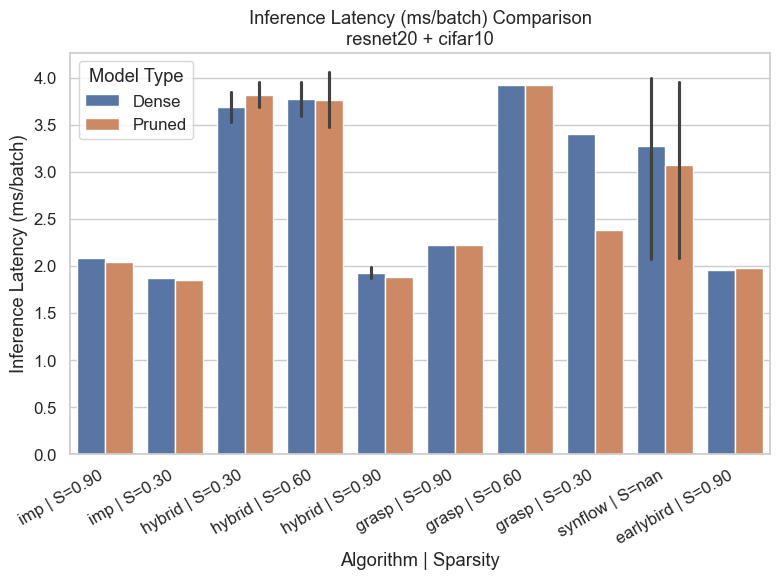

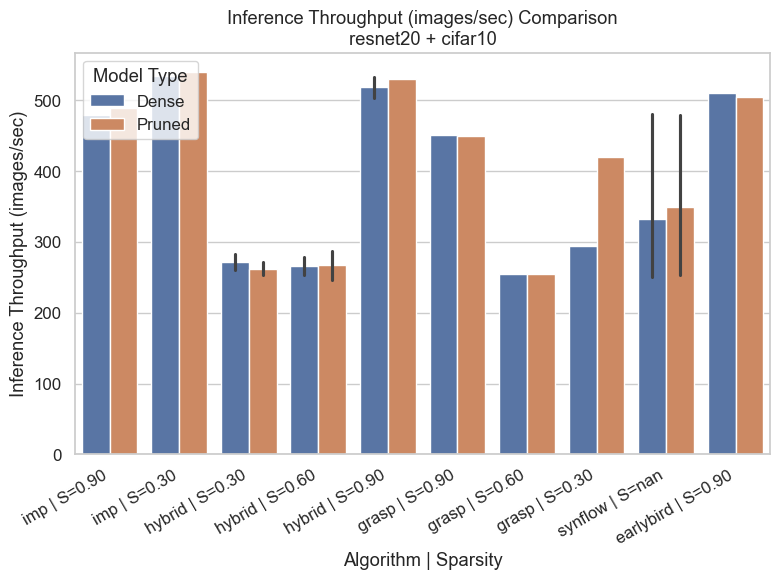

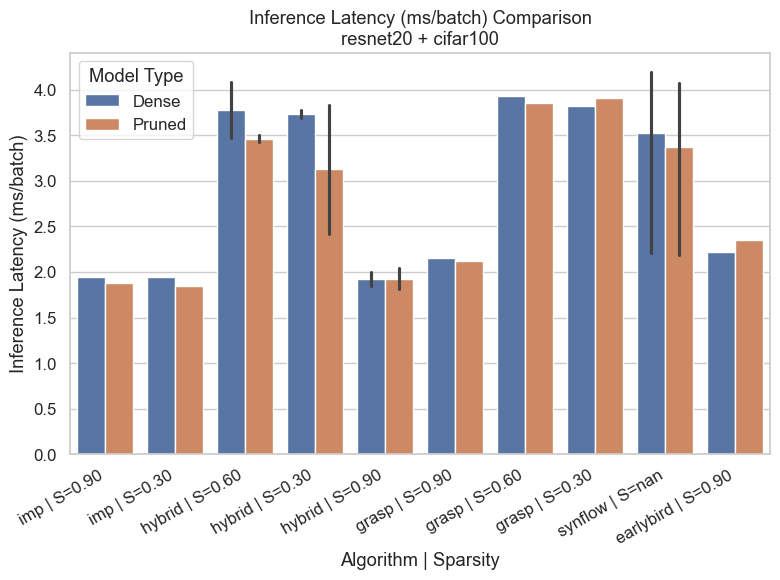

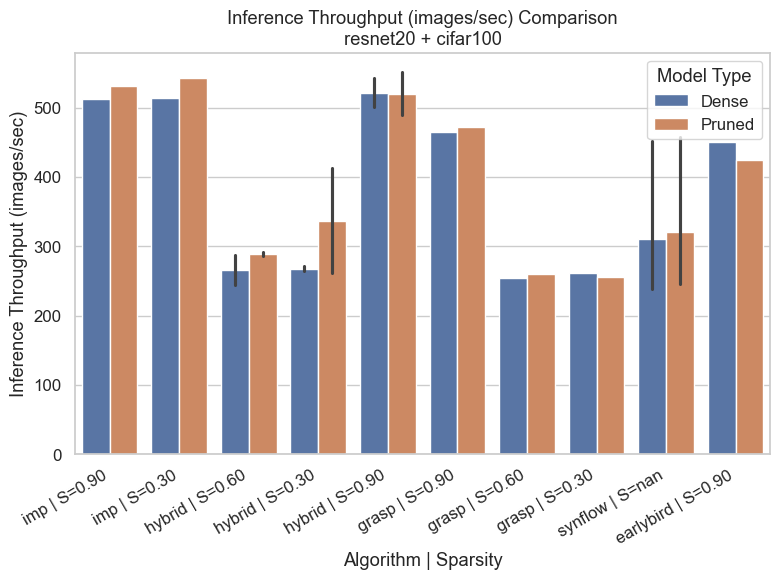

In [12]:
# --- Inference Latency & Throughput Comparison ---
import glob
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all results.json files
results_files = glob.glob(os.path.join('../results', '*', '*', 'results.json'))

latency_records = []
for fpath in results_files:
    with open(fpath, 'r') as f:
        try:
            data = json.load(f)
        except Exception:
            continue
    cfg = data.get('config', {})
    algo = cfg.get('algorithm') or cfg.get('algo') or os.path.basename(os.path.dirname(os.path.dirname(fpath)))
    model = cfg.get('model') or cfg.get('model_name')
    dataset = cfg.get('dataset') or cfg.get('dataset_name')
    sparsity = cfg.get('target_sparsity')
    # Try to extract from experiment name if missing
    if sparsity is None:
        exp_name = os.path.basename(os.path.dirname(fpath))
        import re
        m = re.search(r's(?:parsity)?([0-9]*\.?[0-9]+)', exp_name)
        if m:
            sparsity = float(m.group(1))
    # Try to get from final_results if still missing
    if sparsity is None:
        sparsity = data.get('final_results', {}).get('final_sparsity')
    try:
        sparsity = float(sparsity)
    except Exception:
        sparsity = None
    # Only consider ResNet-20 for fair comparison
    if model is not None and 'resnet20' not in str(model).lower():
        continue
    # Try to get latency/throughput metrics
    fr = data.get('final_results', {})
    dense_latency = fr.get('dense_latency_ms')
    pruned_latency = fr.get('pruned_latency_ms')
    dense_throughput = fr.get('dense_throughput')
    pruned_throughput = fr.get('pruned_throughput')
    if None in (dense_latency, pruned_latency, dense_throughput, pruned_throughput):
        continue
    latency_records.append({
        'algorithm': algo,
        'dataset': dataset,
        'architecture': model,
        'sparsity': sparsity,
        'dense_latency_ms': dense_latency,
        'pruned_latency_ms': pruned_latency,
        'dense_throughput': dense_throughput,
        'pruned_throughput': pruned_throughput,
    })

latency_df = pd.DataFrame(latency_records)
if latency_df.empty:
    raise ValueError('No latency/throughput data found for ResNet-20.')

# Plot for each (dataset, architecture)
sns.set(style="whitegrid", font_scale=1.1)
for (dataset, arch), group in latency_df.groupby(['dataset', 'architecture']):
    for metric, ylabel in [('latency_ms', 'Inference Latency (ms/batch)'), ('throughput', 'Inference Throughput (images/sec)')]:
        plt.figure(figsize=(8, 6))
        plot_df = pd.DataFrame({
            'Algorithm': [],
            'Sparsity': [],
            'Type': [],
            'Value': []
        })
        for _, row in group.iterrows():
            label = f"{row['algorithm']} | S={row['sparsity']:.2f}"
            plot_df = pd.concat([
                plot_df,
                pd.DataFrame({
                    'Algorithm': [label, label],
                    'Sparsity': [row['sparsity'], row['sparsity']],
                    'Type': ['Dense', 'Pruned'],
                    'Value': [row[f'dense_{metric}'], row[f'pruned_{metric}']]
                })
            ], ignore_index=True)
        sns.barplot(
            data=plot_df,
            x='Algorithm',
            y='Value',
            hue='Type',
            dodge=True
        )
        plt.xlabel('Algorithm | Sparsity')
        plt.ylabel(ylabel)
        plt.title(f'{ylabel} Comparison\n{arch} + {dataset}')
        plt.xticks(rotation=30, ha='right')
        plt.legend(title='Model Type')
        plt.tight_layout()
        plt.show()
